In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
from google.colab import files

uploaded = files.upload()

Saving data.zip to data (1).zip


In [4]:
import zipfile
import os

zip_path = "/content/data.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import os

base_dir = "/content/data"

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")

    for class_name in ["Accident", "Non Accident"]:
        path = os.path.join(base_dir, split, class_name)

        print(
            class_name,
            ":",
            len(os.listdir(path)),
            "images"
        )


TRAIN
Accident : 369 images
Non Accident : 422 images

VAL
Accident : 46 images
Non Accident : 52 images

TEST
Accident : 47 images
Non Accident : 54 images


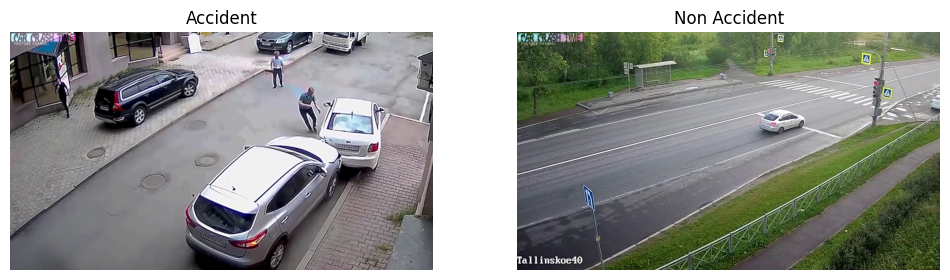

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

plt.figure(figsize=(12, 8))

classes = ["Accident", "Non Accident"]

for i, class_name in enumerate(classes):

    folder = os.path.join(
        base_dir,
        "train",
        class_name
    )

    image_name = random.choice(os.listdir(folder))

    image_path = os.path.join(
        folder,
        image_name
    )

    image = Image.open(image_path)

    plt.subplot(1, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [7]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 791 files belonging to 2 classes.
Found 98 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [8]:
print(train_ds.class_names)

['Accident', 'Non Accident']


In [9]:
tf.keras.layers.Rescaling(1./255)

<Rescaling name=rescaling, built=False>

In [10]:
from tensorflow.keras import layers, models

cnn_scratch = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [11]:
cnn_scratch.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
cnn_scratch.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
EPOCHS = 20

In [14]:
history_scratch = cnn_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 386ms/step - accuracy: 0.5234 - loss: 0.6911 - val_accuracy: 0.5306 - val_loss: 0.6912
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.5145 - loss: 0.6909 - val_accuracy: 0.5306 - val_loss: 0.6904
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.5234 - loss: 0.6956 - val_accuracy: 0.5306 - val_loss: 0.6903
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - accuracy: 0.5171 - loss: 0.6935 - val_accuracy: 0.5306 - val_loss: 0.6905
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - accuracy: 0.5360 - loss: 0.6900 - val_accuracy: 0.5306 - val_loss: 0.6903
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.5335 - loss: 0.6931 - val_accuracy: 0.5306 - val_loss: 0.6903
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.5310 - loss: 0.6923 - val_accuracy: 0.5306 - val_loss: 0.6901
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.5247 - loss: 0.6928 - val_accuracy: 0

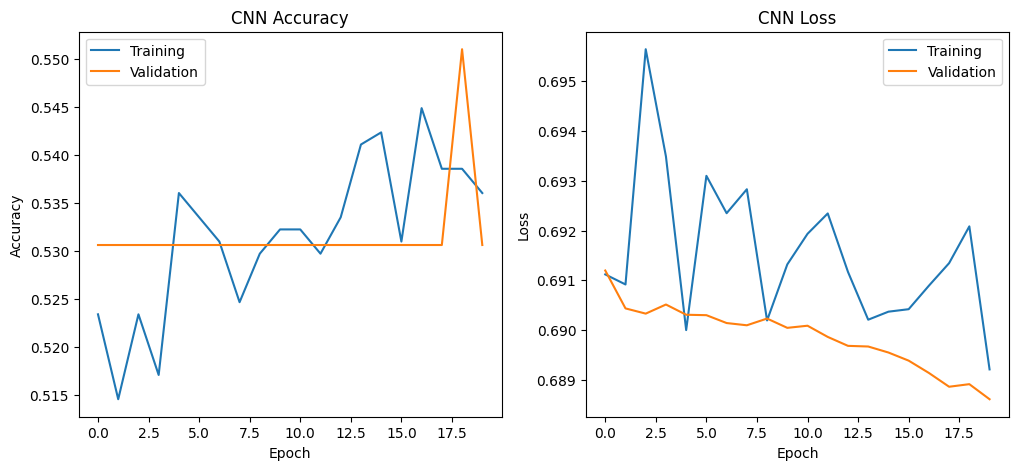

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(history_scratch.history["accuracy"])
plt.plot(history_scratch.history["val_accuracy"])

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training", "Validation"])


plt.subplot(1, 2, 2)

plt.plot(history_scratch.history["loss"])
plt.plot(history_scratch.history["val_loss"])

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training", "Validation"])

plt.show()

In [16]:
test_loss, test_accuracy = cnn_scratch.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 321ms/step - accuracy: 0.5300 - loss: 0.6909
Test Loss: 0.6909114122390747
Test Accuracy: 0.5299999713897705


In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = cnn_scratch.predict(
        images,
        verbose=0
    )

    predictions = (predictions >= 0.5).astype(int).flatten()

    y_true.extend(labels.numpy().astype(int).flatten())
    y_pred.extend(predictions)

cm = confusion_matrix(y_true, y_pred)

print(cm)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_ds.class_names
    )
)

[[ 0 47]
 [ 0 53]]
              precision    recall  f1-score   support

    Accident       0.00      0.00      0.00        47
Non Accident       0.53      1.00      0.69        53

    accuracy                           0.53       100
   macro avg       0.27      0.50      0.35       100
weighted avg       0.28      0.53      0.37       100



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [19]:
resnet_base.trainable = False

In [20]:
resnet_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(
        1./127.5,
        offset=-1
    ),

    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [21]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [22]:
history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 706ms/step - accuracy: 0.5095 - loss: 0.7109 - val_accuracy: 0.6633 - val_loss: 0.6742
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - accuracy: 0.5752 - loss: 0.6829 - val_accuracy: 0.6327 - val_loss: 0.6641
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.5841 - loss: 0.6809 - val_accuracy: 0.6429 - val_loss: 0.6561
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.5714 - loss: 0.6807 - val_accuracy: 0.6531 - val_loss: 0.6465
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.5815 - loss: 0.6704 - val_accuracy: 0.6633 - val_loss: 0.6386
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - accuracy: 0.5954 - loss: 0.6635 - val_accuracy: 0.6429 - val_loss: 0.6334
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - accuracy: 0.6131 - loss: 0.6595 - val_accuracy: 0.6735 - val_loss: 0.6283
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - accuracy: 0.6536 - loss: 0.6416 - val_accuracy: 0

In [23]:
resnet_test_loss, resnet_test_accuracy = resnet_model.evaluate(
    test_ds
)

print(
    "ResNet50 Test Accuracy:",
    resnet_test_accuracy
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6900 - loss: 0.6532
ResNet50 Test Accuracy: 0.6899999976158142


In [24]:
from tensorflow.keras.applications import VGG16

vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

vgg_base.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [25]:
vgg_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(
        1./127.5,
        offset=-1
    ),

    vgg_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [26]:
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [27]:
history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 842ms/step - accuracy: 0.4829 - loss: 0.7342 - val_accuracy: 0.6020 - val_loss: 0.6747
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 188ms/step - accuracy: 0.5487 - loss: 0.6981 - val_accuracy: 0.6122 - val_loss: 0.6648
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.5575 - loss: 0.6862 - val_accuracy: 0.6327 - val_loss: 0.6554
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.5702 - loss: 0.6805 - val_accuracy: 0.6429 - val_loss: 0.6475
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.5525 - loss: 0.6868 - val_accuracy: 0.6531 - val_loss: 0.6406
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 228ms/step - accuracy: 0.6018 - loss: 0.6709 - val_accuracy: 0.6531 - val_loss: 0.6343
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step - accuracy: 0.6308 - loss: 0.6507 - val_accuracy: 0.6429 - val_loss: 0.6277
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.5992 - loss: 0.6547 - val_accuracy: 0

In [28]:
vgg_test_loss, vgg_test_accuracy = vgg_model.evaluate(
    test_ds
)

print(
    "VGG16 Test Accuracy:",
    vgg_test_accuracy
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6600 - loss: 0.6264
VGG16 Test Accuracy: 0.6600000262260437


In [29]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.10
    ),

    layers.RandomZoom(
        0.10
    ),

    layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    )
])

In [30]:
cnn_augmented = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [31]:
cnn_augmented.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [32]:
history_cnn_aug = cnn_augmented.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 170ms/step - accuracy: 0.5284 - loss: 0.6926 - val_accuracy: 0.5306 - val_loss: 0.6910
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 204ms/step - accuracy: 0.5335 - loss: 0.6909 - val_accuracy: 0.5306 - val_loss: 0.6907
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - accuracy: 0.5322 - loss: 0.6923 - val_accuracy: 0.5306 - val_loss: 0.6907
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.5373 - loss: 0.6907 - val_accuracy: 0.5306 - val_loss: 0.6908
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - accuracy: 0.5335 - loss: 0.6915 - val_accuracy: 0.5306 - val_loss: 0.6908
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 211ms/step - accuracy: 0.5411 - loss: 0.6900 - val_accuracy: 0.5306 - val_loss: 0.6908
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.5360 - loss: 0.6908 - val_accuracy: 0.5306 - val_loss: 0.6909
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.5247 - loss: 0.6913 - val_accuracy: 0

In [33]:
resnet_augmented = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Rescaling(
        1./127.5,
        offset=-1
    ),

    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [34]:
resnet_augmented.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [35]:
history_resnet_aug = resnet_augmented.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 278ms/step - accuracy: 0.4652 - loss: 0.8495 - val_accuracy: 0.5612 - val_loss: 0.6811
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step - accuracy: 0.5171 - loss: 0.7706 - val_accuracy: 0.5510 - val_loss: 0.6778
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.5183 - loss: 0.7413 - val_accuracy: 0.5714 - val_loss: 0.6791
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.5424 - loss: 0.7185 - val_accuracy: 0.6020 - val_loss: 0.6703
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.4981 - loss: 0.7262 - val_accuracy: 0.6224 - val_loss: 0.6690
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - accuracy: 0.5550 - loss: 0.7076 - val_accuracy: 0.6224 - val_loss: 0.6664
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - accuracy: 0.5424 - loss: 0.7068 - val_accuracy: 0.5816 - val_loss: 0.6655
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.5613 - loss: 0.6838 - val_accuracy: 0

In [36]:
vgg_augmented = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Rescaling(
        1./127.5,
        offset=-1
    ),

    vgg_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [37]:
vgg_augmented.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [38]:
history_vgg_aug = vgg_augmented.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 289ms/step - accuracy: 0.5259 - loss: 0.7404 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.5183 - loss: 0.7215 - val_accuracy: 0.5714 - val_loss: 0.6868
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.5360 - loss: 0.7259 - val_accuracy: 0.5612 - val_loss: 0.6829
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.5360 - loss: 0.7267 - val_accuracy: 0.5918 - val_loss: 0.6771
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.5386 - loss: 0.6975 - val_accuracy: 0.6327 - val_loss: 0.6746
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - accuracy: 0.5373 - loss: 0.7060 - val_accuracy: 0.5918 - val_loss: 0.6709
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - accuracy: 0.5360 - loss: 0.7052 - val_accuracy: 0.6327 - val_loss: 0.6715
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - accuracy: 0.5537 - loss: 0.6959 - val_accuracy: 0

In [39]:
results = {
    "CNN Scratch": cnn_scratch.evaluate(test_ds, verbose=0)[1],

    "ResNet50": resnet_model.evaluate(
        test_ds,
        verbose=0
    )[1],

    "VGG16": vgg_model.evaluate(
        test_ds,
        verbose=0
    )[1],

    "CNN + Augmentation": cnn_augmented.evaluate(
        test_ds,
        verbose=0
    )[1],

    "ResNet50 + Augmentation": resnet_augmented.evaluate(
        test_ds,
        verbose=0
    )[1],

    "VGG16 + Augmentation": vgg_augmented.evaluate(
        test_ds,
        verbose=0
    )[1]
}

for model_name, accuracy in results.items():

    print(
        f"{model_name}: {accuracy:.4f}"
    )

CNN Scratch: 0.5300
ResNet50: 0.6900
VGG16: 0.6600
CNN + Augmentation: 0.5300
ResNet50 + Augmentation: 0.5500
VGG16 + Augmentation: 0.6200


In [40]:
for model_name, accuracy in results.items():

    print(
        f"{model_name}: {accuracy * 100:.2f}%"
    )

CNN Scratch: 53.00%
ResNet50: 69.00%
VGG16: 66.00%
CNN + Augmentation: 53.00%
ResNet50 + Augmentation: 55.00%
VGG16 + Augmentation: 62.00%


In [41]:
scratch_train_acc = history_scratch.history["accuracy"][-1]
resnet_train_acc = history_resnet.history["accuracy"][-1]
vgg_train_acc = history_vgg.history["accuracy"][-1]

cnn_aug_train_acc = history_cnn_aug.history["accuracy"][-1]
resnet_aug_train_acc = history_resnet_aug.history["accuracy"][-1]
vgg_aug_train_acc = history_vgg_aug.history["accuracy"][-1]

In [42]:
comparison = [
    ["CNN Scratch",
     scratch_train_acc,
     results["CNN Scratch"]],

    ["ResNet50",
     resnet_train_acc,
     results["ResNet50"]],

    ["VGG16",
     vgg_train_acc,
     results["VGG16"]],

    ["CNN + Augmentation",
     cnn_aug_train_acc,
     results["CNN + Augmentation"]],

    ["ResNet50 + Augmentation",
     resnet_aug_train_acc,
     results["ResNet50 + Augmentation"]],

    ["VGG16 + Augmentation",
     vgg_aug_train_acc,
     results["VGG16 + Augmentation"]]
]

import pandas as pd

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "Model",
        "Training Accuracy",
        "Test Accuracy"
    ]
)

comparison_df["Training Accuracy"] *= 100
comparison_df["Test Accuracy"] *= 100

comparison_df

,Model,Training Accuracy,Test Accuracy
0,CNN Scratch,53.603035,52.999997
1,ResNet50,63.211125,69.000000
2,VGG16,62.705433,66.000003
3,CNN + Augmentation,53.603035,52.999997
4,ResNet50 + Augmentation,55.120099,55.000001
5,VGG16 + Augmentation,54.235142,62.000000


In [43]:
comparison_df["Generalization Gap"] = (
    comparison_df["Training Accuracy"]
    - comparison_df["Test Accuracy"]
)

comparison_df

,Model,Training Accuracy,Test Accuracy,Generalization Gap
0,CNN Scratch,53.603035,52.999997,0.603038
1,ResNet50,63.211125,69.000000,-5.788875
2,VGG16,62.705433,66.000003,-3.294569
3,CNN + Augmentation,53.603035,52.999997,0.603038
4,ResNet50 + Augmentation,55.120099,55.000001,0.120097
5,VGG16 + Augmentation,54.235142,62.000000,-7.764858
